# Algoritmos Wikimedia

Alumnos:

*   Alonso Casanova
*   Bruno Cerda




## Librerías

In [ ]:
!pip3 install implicit --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=f99dd02bb01eef390abc96cf82afb29edba45f45f23ecfccc308650523236103
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [ ]:
import numpy as np
import pandas as pd
import implicit
import scipy.sparse as sparse

In [ ]:
semilla = 11
np.random.seed(semilla)
# he notado que los resultados que te salen a ti difieren mucho de los mios

## Datos

In [ ]:
!unzip OneDrive_2026-03-25.zip
!mv -f Datasets\ Tarea\ \(p├║blico\) Datos

Archive:  OneDrive_2026-03-25.zip
 extracting: Datasets Tarea (p├║blico)/competicion_ranking.json  
 extracting: Datasets Tarea (p├║blico)/competicion_rating.txt  
 extracting: Datasets Tarea (p├║blico)/wikimedia_image_embeddings.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_item_id_to_idx.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_train.csv  
 extracting: Datasets Tarea (p├║blico)/wikimedia_validation.csv  
 extracting: Datasets Tarea (p├║blico)/ydata_artists.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_train.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_val.txt  


In [ ]:
wikimedia_train = pd.read_csv("Datos/wikimedia_train.csv", header=None)
wikimedia_train.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_train = wikimedia_train.iloc[1:]

wikimedia_validation = pd.read_csv("Datos/wikimedia_validation.csv", header=None)
wikimedia_validation.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_validation = wikimedia_validation.iloc[1:]

wikimedia_embeddings = np.load('Datos/wikimedia_image_embeddings.npy')

wikimedia_item_id_to_embedding_id = np.load('Datos/wikimedia_item_id_to_idx.npy', allow_pickle=True)

In [ ]:
wikimedia_train.head()

,user_id,item_id,timestamp,evaluation
1,1,200502005,1108503300,False
2,1,200504028,1113243060,False
3,1,200504029,1113243060,False
4,1,200504034,1113246480,False
5,1,200504035,1113246600,False


In [ ]:
wikimedia_validation.head()

,user_id,item_id,timestamp,evaluation
1,1,200601034,1135542960,False
2,1,200601057,1135630920,False
3,1,200601058,1135643700,False
4,1,200601059,1135643700,False
5,6,200508088,1124907120,False


In [ ]:
def recall_at_k(recs, gt, k):
    recalls = []
    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        hits = len(set(top_k) & relevant)
        recalls.append(hits / len(relevant))

    return np.mean(recalls)

## ALS

In [ ]:
# Codigo ayudantia

# Diccionario validatioon

user_items_test = {}

for row in wikimedia_validation.itertuples():
    if row[1] not in user_items_test:
        user_items_test[row[1]] = []

    user_items_test[row[1]].append(row[2])

# Diccionario train

user_items = {}
itemset = set()

for row in wikimedia_train.itertuples():
    if row[1] not in user_items:
        user_items[row[1]] = []

    user_items[row[1]].append(row[2])
    itemset.add(row[2])

itemset = np.sort(list(itemset))

sparse_matrix = np.zeros((len(user_items), len(itemset)))

for i, items in enumerate(user_items.values()):
    sparse_matrix[i] = np.isin(itemset, items, assume_unique=True).astype(int)

matrix = sparse.csr_matrix(sparse_matrix.T)
user_item_matrix = matrix.T.tocsr()

# Mapeo de user id a fila de la matriz sparse
user2row = {user_id: matrix_row for matrix_row, user_id in enumerate(user_items.keys())}
row2user = {matrix_row: user_id for user_id, matrix_row in user2row.items()}

# Mapeo de item id a columna de la matriz sparse
item2col = {item_id: matrix_col for matrix_col, item_id in enumerate(itemset)}
col2item = {matrix_col: item_id for item_id, matrix_col in item2col.items()}

In [ ]:
# Metricas, codigo ayudantia

def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()


def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum() # Número de items relevantes
    if n_rel == 0:
        return 0.
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(indices) # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)


def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg


def evaluate_model(model, n):
  mean_ap = 0. # o MAP
  mean_ndcg = 0.
  mean_recall = 0.
  for user_id in user_items_test.keys():
    user_row = user2row[user_id]
    rec = model.recommend(user_row, user_item_matrix[user_row], n)[0]
    rec = [col2item[col] for col in rec]
    rel_vector = np.isin(rec, user_items_test[user_id], assume_unique=True).astype(int)
    mean_ap += average_precision_at_k(rel_vector, n)
    mean_ndcg += ndcg_at_k(rel_vector, n)
    # Codigo que agregue yo para calc recall
    num_relevant = len(user_items_test[user_id])
    if num_relevant > 0:
        hits = np.sum(rel_vector)
        mean_recall += hits / num_relevant

  mean_ap /= len(user_items_test)
  mean_ndcg /= len(user_items_test)
  mean_recall /= len(user_items_test)

  return mean_ap, mean_ndcg, mean_recall

In [ ]:
# Entrenamiento, codigo ayudantia

# Definimos y entrenamos el modelo con optimización ALS

n_factors = [10, 50, 100, 150, 200, 250, 300]

n_map = []
n_ndcg = []
n_recall = []
for factor in n_factors:
  model_als = implicit.als.AlternatingLeastSquares(factors=factor, iterations=10, use_gpu=False)
  model_als.fit(user_item_matrix)
  maprec, ndcg, recall = evaluate_model(model_als, n=10)
  n_map.append(maprec)
  n_ndcg.append(ndcg)
  n_recall.append(recall)

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

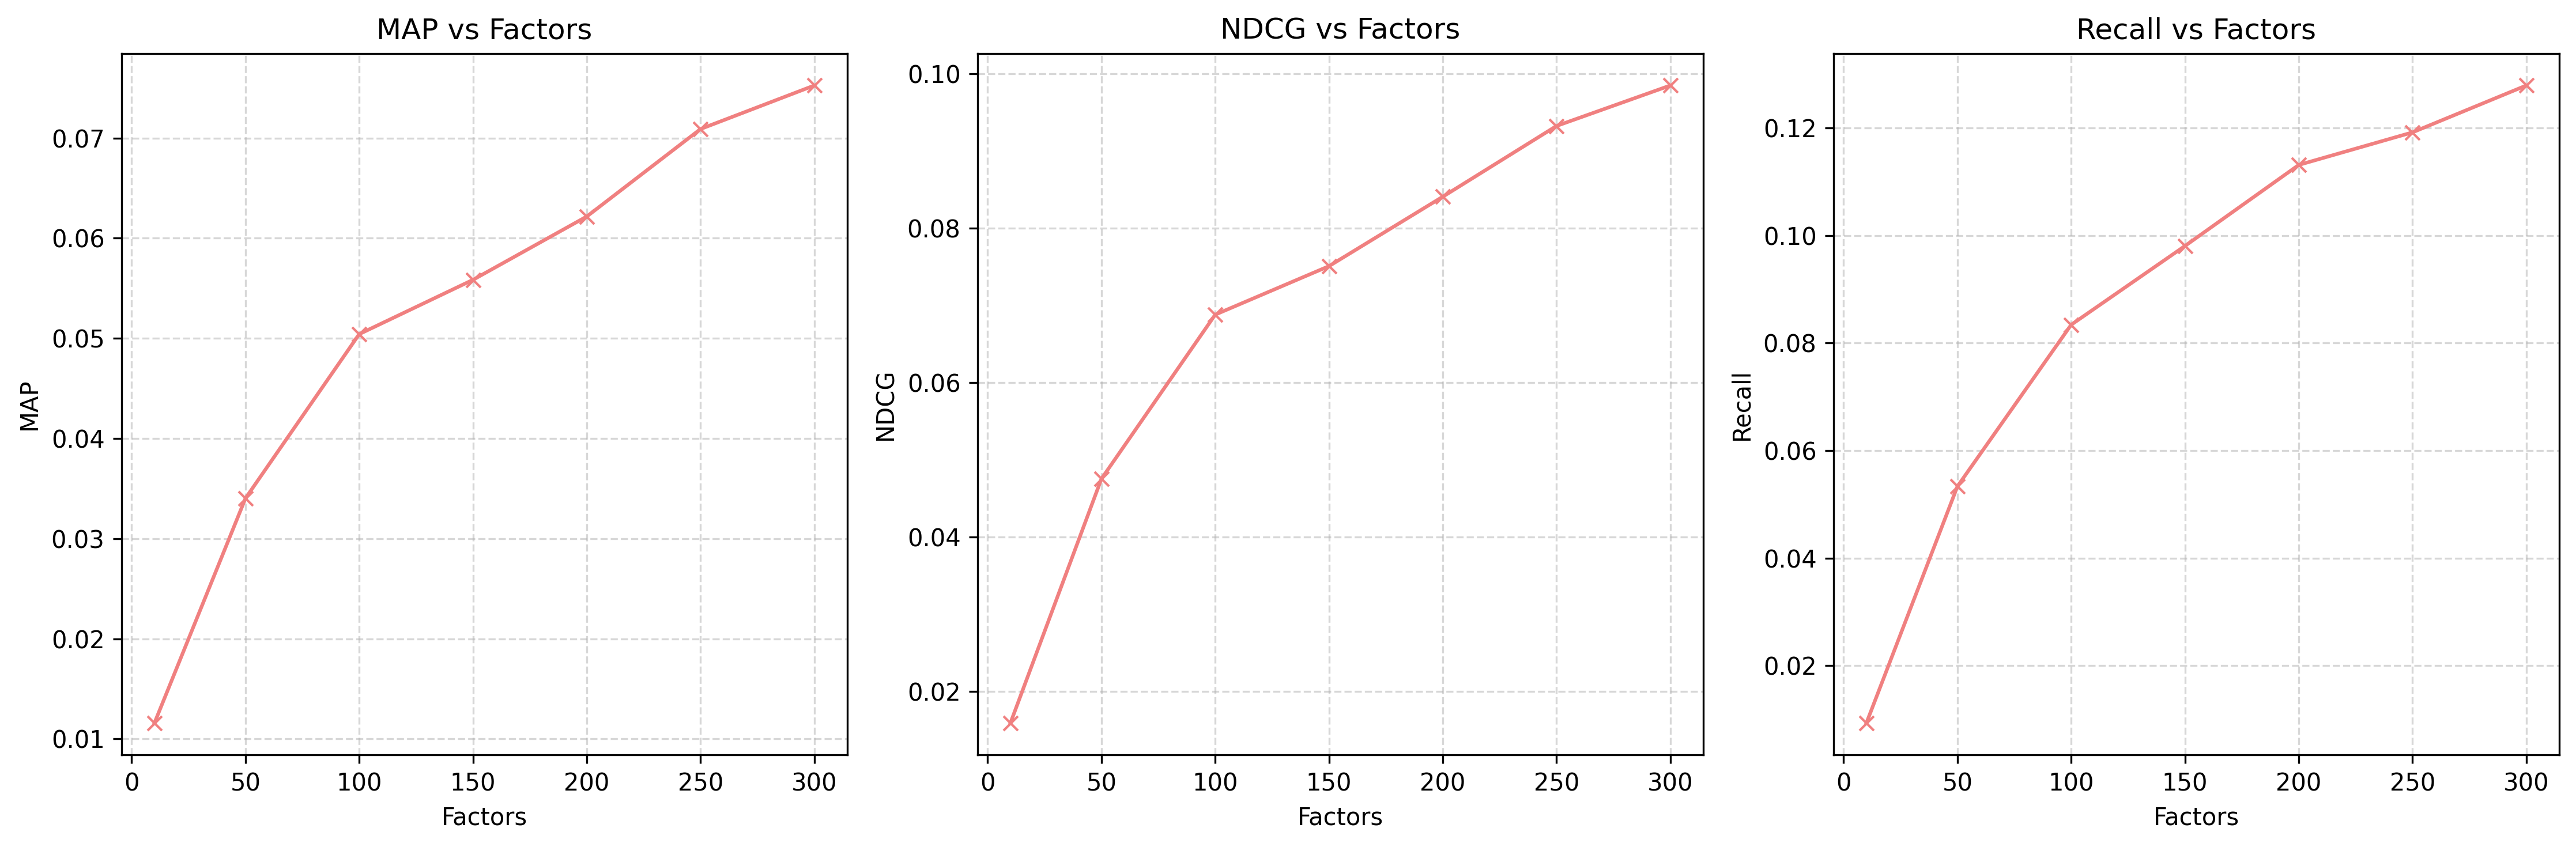

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

axes[0].plot(n_factors, [metric for metric in n_map], color='lightcoral', marker='x')
axes[0].set_title('MAP vs Factors')
axes[0].set_xlabel('Factors')
axes[0].set_ylabel('MAP')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(n_factors, [metric for metric in n_ndcg], color='lightcoral', marker='x')
axes[1].set_title('NDCG vs Factors')
axes[1].set_xlabel('Factors')
axes[1].set_ylabel('NDCG')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(n_factors, [metric for metric in n_recall], color='lightcoral', marker='x')
axes[2].set_title('Recall vs Factors')
axes[2].set_xlabel('Factors')
axes[2].set_ylabel('Recall')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('als-sens.jpeg')
plt.show()

## BPR

In [ ]:
# Entrenamiento, codigo ayudantia

# Definimos y entrenamos el modelo con optimización ALS

n_factors = [100, 200, 300, 400, 500, 600, 700]

n_map_bpr = []
n_ndcg_bpr = []
n_recall_bpr = []
for factor in n_factors:
  model_bpr = implicit.bpr.BayesianPersonalizedRanking(factors=factor, iterations=40, use_gpu=False)
  model_bpr.fit(user_item_matrix)
  maprec, ndcg, recall = evaluate_model(model_bpr, n=10)
  n_map_bpr.append(maprec)
  n_ndcg_bpr.append(ndcg)
  n_recall_bpr.append(recall)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

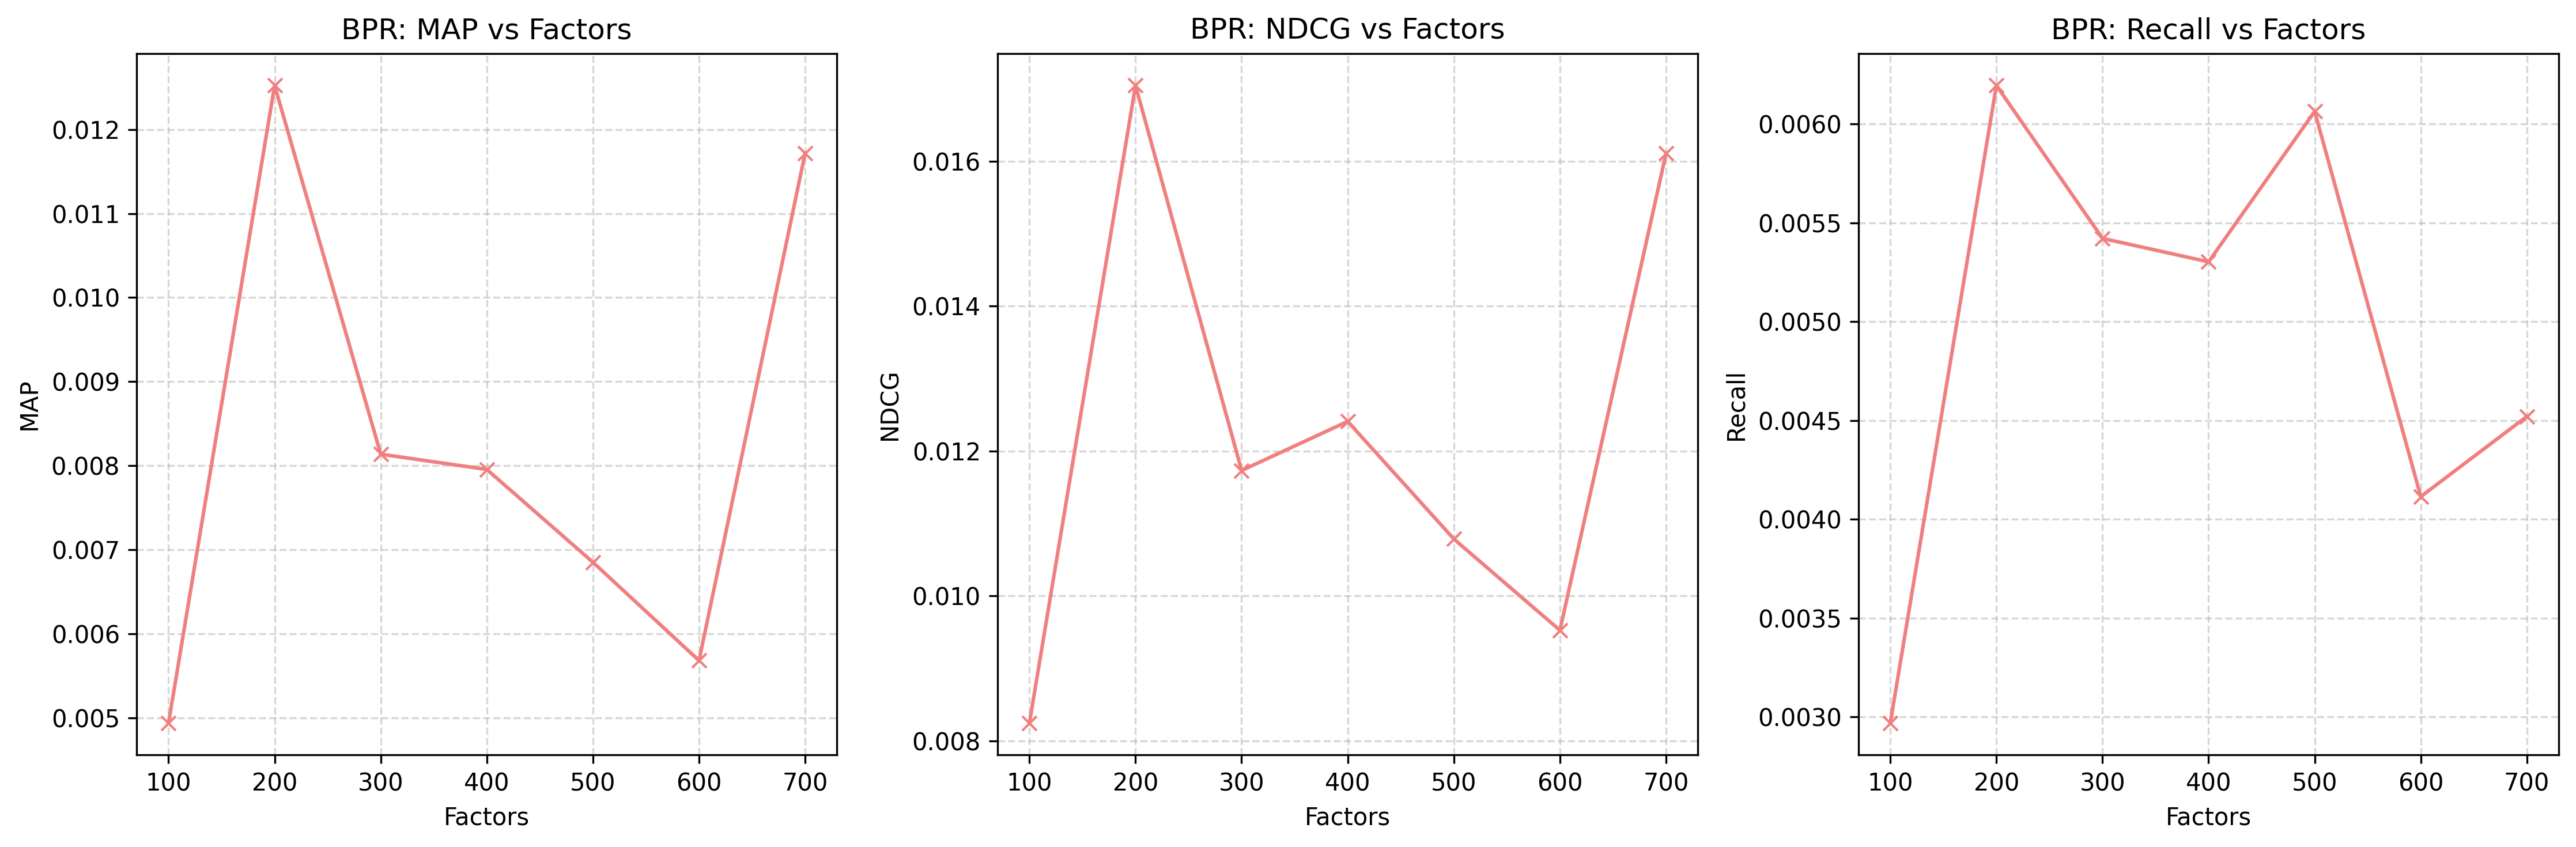

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

axes[0].plot(n_factors, [metric for metric in n_map_bpr], color='lightcoral', marker='x')
axes[0].set_title('BPR: MAP vs Factors')
axes[0].set_xlabel('Factors')
axes[0].set_ylabel('MAP')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(n_factors, [metric for metric in n_ndcg_bpr], color='lightcoral', marker='x')
axes[1].set_title('BPR: NDCG vs Factors')
axes[1].set_xlabel('Factors')
axes[1].set_ylabel('NDCG')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(n_factors, [metric for metric in n_recall_bpr], color='lightcoral', marker='x')
axes[2].set_title('BPR: Recall vs Factors')
axes[2].set_xlabel('Factors')
axes[2].set_ylabel('Recall')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('bpr-sens.jpeg')
plt.show()

## Content based

In [ ]:
# Métricas de evaluación
# Obtenido de https://gist.github.com/bwhite/3726239

def precision_at_k(r, k):
    assert k >= 1
    r = np.asarray(r)[:k] != 0
    if r.size != k:
        raise ValueError('Relevance score length < k')
    return np.mean(r)

def average_precision(r):
    r = np.asarray(r) != 0
    out = [precision_at_k(r, k + 1) for k in range(r.size) if r[k]]
    if not out:
        return 0.
    return np.mean(out)

def mean_average_precision(rs):
    return np.mean([average_precision(r) for r in rs])

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Matriz cuadrada de similitudes coseno entre imagenes
cos_sim_matrix = cosine_similarity(wikimedia_embeddings)

In [ ]:
def recommend(user, user_items_dict, wikimedia_item_id_to_idx, cos_sim_matrix, top_k):

  # Indices items
  items = user_items[user]
  # Indices embeddings de los items
  embedding_idxs = [wikimedia_item_id_to_idx.item()[int(item)] for item in items]

  # Lista que contiene para cada embedding su similitud coseno con el resto de los items
  cos_sim_arrays = [cos_sim_matrix[idx, :] for idx in embedding_idxs]
  # Stack vertical de los vectores de cos_sim_arrays
  cos_sim_stack = np.vstack(cos_sim_arrays)

  # Por columna, mantenemos las similitudes mas grandes
  cos_sim_vector_max = np.max(cos_sim_stack, axis=0)
  # Asignamos menos infinito a los items que el usuario ya visitó
  cos_sim_vector_max[embedding_idxs] = -np.inf

  # Sorteamos y retornamos indices de las top 10 recomendaciones de imagenes
  top_10_idxs = np.argsort(cos_sim_vector_max)[-top_k:][::-1]

  return top_10_idxs

In [ ]:
mean_map = 0.
mean_ndcg = 0.
mean_recall = 0.

idx_to_item = {idx: item for item, idx in wikimedia_item_id_to_embedding_id.item().items()}

for user in user_items_test.keys():
    rec_embedding_idxs = recommend(user, user_items, wikimedia_item_id_to_embedding_id, cos_sim_matrix, 10)
    rec = [idx_to_item[idx] for idx in rec_embedding_idxs]
    rel_vector = np.isin(rec, user_items_test[user]).astype(int)
    mean_map += mean_average_precision([rel_vector])
    mean_ndcg += ndcg_at_k(rel_vector, 10)

    num_relevant = len(user_items_test[user])
    if num_relevant > 0:
        hits = np.sum(rel_vector)
        mean_recall += hits / num_relevant

mean_map /= len(user_items_test.keys())
mean_ndcg /= len(user_items_test.keys())
mean_recall /= len(user_items_test.keys())

In [ ]:
print(mean_map)
print(mean_ndcg)
print(mean_recall)

0.003808047249907715
0.005381009394342776
0.0004242843334812471
